# Hyperparameter Sweep: SQP Planning + MPC Tracking

This notebook sweeps key hyperparameters of the SQP offline planner + MPC tracking controller
framework and visualizes the effect of each on landing performance metrics.

**Metrics collected per run:**
- Landing position error (m)
- Landing velocity magnitude (m/s)
- Final angle at touchdown (rad)
- Total control effort (sum of squared controls)
- Mean SQP iterations per MPC step
- Mean solve time per MPC step (s)
- Number of solver failures
- Whether the rocket crashed

**Parameters swept (one at a time around a fixed baseline):**
1. MPC horizon length
2. Max SQP iterations per MPC step
3. State trust region penalty
4. Control trust region penalty
5. Robustness: disturbance magnitude

## Imports

In [2]:
import functools
import time
import warnings
from typing import Callable

import cvxpy as cp
import dynamaxsys
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import pandas as pd
from joblib import Parallel, delayed

from RocketDynamics import RocketDynamics
from utils import (
    PD_controller,
    closed_loop_sim,
    open_loop_sim,
    plot_rocket_trajectory,
)
from scp_mpc import SQP, linearize_trajectory, build_mpc_problem, run_mpc

warnings.filterwarnings('ignore')
jax.config.update('jax_enable_x64', True)

# ── plotting style ───────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': '#0f1117',
    'axes.facecolor':   '#1a1d27',
    'axes.edgecolor':   '#3a3d4d',
    'axes.labelcolor':  '#c8ccd8',
    'axes.titlesize':   16,
    'axes.labelsize':   14,
    'axes.grid':        True,
    'figure.titlesize': 20,
    'grid.color':       '#2a2d3d',
    'grid.linewidth':   0.6,
    'xtick.color':      '#7a7d8d',
    'ytick.color':      '#7a7d8d',
    'text.color':       '#c8ccd8',
    'legend.facecolor': '#1a1d27',
    'legend.edgecolor': '#3a3d4d',
    'legend.fontsize':  12,
    'font.family':      'monospace',
    'lines.linewidth':  1.8,
})

# accent palette used throughout
ACCENT   = ['#4fc3f7', '#81c784', '#ffb74d', '#e57373', '#ce93d8', '#80deea']
BASELINE_COLOR = '#4fc3f7'
MARKER   = 'o'
print('Imports complete.')

Imports complete.


## Rocket dynamics setup

In [3]:
params = {
    'mass_thruster': 10.0,
    'mass_body':     15.0,
    'length':        1.0,
    'gravity':       9.81,
}
rocket_ct = RocketDynamics(params)
dt        = 0.01
rocket_dt = dynamaxsys.get_discrete_time_dynamics(rocket_ct, dt=dt)

thrust_to_weight  = 1.3
rocket_weight     = (params['mass_thruster'] + params['mass_body']) * params['gravity']
T_base_z_max      = rocket_weight * thrust_to_weight
T_base_x_max      = T_base_z_max  * 0.75
T_nose_max        = T_base_x_max  * 0.75

lower_control_limit = jnp.array([-T_base_x_max, 0.0,          -T_nose_max])
upper_control_limit = jnp.array([ T_base_x_max, T_base_z_max,  T_nose_max])
limits              = [lower_control_limit, upper_control_limit]

state_dim   = rocket_ct.state_dim
control_dim = rocket_ct.control_dim
THETA_LIMIT = 0.25   # rad

INITIAL_STATE = jnp.array([1.0, 7.0, 0.1, 0.2, -0.1, -0.05])
TARGET_STATE  = jnp.array([0.0, 0.0, 0.0, 0.0,  0.0,  0.0])

print(f'state_dim={state_dim}, control_dim={control_dim}')
print(f'Control limits: lower={np.array(lower_control_limit).round(1)}, upper={np.array(upper_control_limit).round(1)}')

state_dim=6, control_dim=3
Control limits: lower=[-239.1    0.  -179.3], upper=[239.1 318.8 179.3]


## Baseline hyperparameters

In [4]:
BASELINE = {
    # problem dimensions
    'n_steps_total':   300,
    'mpc_horizon':      30,

    # SQP solver settings
    'max_sqp_iterations_tracking': 3,
    'sqp_convergence_tol':         1e-3,

    # running state / control costs
    'state_costs_mpc':   np.array([10.0, 10.0, 10.0, 10.0, 10.0, 10.0]),
    'control_costs_mpc': np.array([ 1.0,  1.0,  1.0]),

    # terminal cost
    'terminal_state_costs_mpc': np.array([1.0, 10.0, 20.0, 0.5, 0.5, 10.0]) * 100,

    # trust region
    'state_trust_region_penalty_mpc':   10.0,
    'control_trust_region_penalty_mpc': 10.0,

    # slack penalties
    'theta_limit_slack_penalty':    1e5,
    'above_ground_slack_penalty':   1e3,

    # geometry
    'theta_limit': THETA_LIMIT,
}

# SQP planning problem settings (fixed for all sweep runs)
PLANNING_PARAMS = {
    'max_sqp_iterations_planning': 100,
    'sqp_convergence_tol':         1e-3,
    'state_costs_sqp':             np.array([1.0, 0.0, 20.0, 0.5, 0.5, 10.0]),
    'control_costs_sqp':           np.array([0.0001, 0.0001, 0.0]),
    'terminal_state_costs_sqp':    np.array([1.0, 5.0, 10.0, 10.0, 8.0, 5.0]) * 1000,
    'state_trust_region_penalty_sqp':   100.0,
    'control_trust_region_penalty_sqp': 100.0,
}
print('Baseline defined.')

Baseline defined.


## Generate nominal trajectory (offline SQP — run once)

Running offline SQP to generate nominal trajectory...
SQP iteration 1/100	 Status: optimal	 Cost: 29782.95076539685
SQP iteration 2/100	 Status: optimal	 Cost: 28671.104846963717
SQP iteration 3/100	 Status: optimal	 Cost: 27619.6819587351
SQP iteration 4/100	 Status: optimal	 Cost: 26632.065852231328
SQP iteration 5/100	 Status: optimal	 Cost: 25714.74801806396
SQP iteration 6/100	 Status: optimal	 Cost: 24882.88318269181
SQP iteration 7/100	 Status: optimal	 Cost: 24117.754465276048
SQP iteration 8/100	 Status: optimal	 Cost: 23413.288624134446
SQP iteration 9/100	 Status: optimal	 Cost: 22765.87017735194
SQP iteration 10/100	 Status: optimal	 Cost: 22187.581247643593
SQP iteration 11/100	 Status: optimal	 Cost: 21661.067371618847
SQP iteration 12/100	 Status: optimal	 Cost: 21180.493943541536
SQP iteration 13/100	 Status: optimal	 Cost: 20742.47201738742
SQP iteration 14/100	 Status: optimal	 Cost: 20344.013464016298
SQP iteration 15/100	 Status: optimal	 Cost: 19982.260749040735
SQ

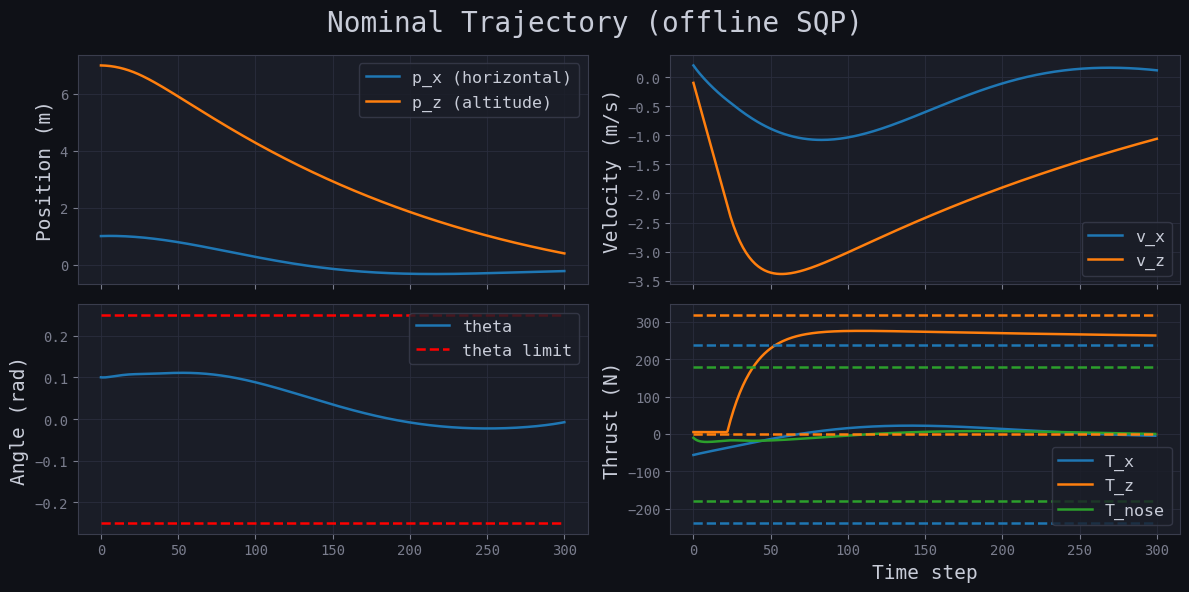

In [5]:
# ── PD warm-start for SQP ────────────────────────────────────────────────────
gains = {
    'Kp_x': 50.0, 'Kd_x': 30.0,
    'Kp_z': 50.0, 'Kd_z': 150.0,
    'Kp_theta': 150.0, 'Kd_theta': 100.0,
}.values()
controller = functools.partial(
    PD_controller,
    target=np.array(TARGET_STATE),
    gains=gains,
    limits=limits,
)
n_steps_total = BASELINE['n_steps_total']
pd_states, pd_controls = closed_loop_sim(
    rocket_dt, np.array(INITIAL_STATE), controller, n_steps_total
)
initial_guess_sqp = {'states': np.array(pd_states), 'controls': np.array(pd_controls)}

# ── Build planning problem ────────────────────────────────────────────────────
def build_planning_problem(n_steps, p):
    """Build the full-horizon SQP planning problem."""
    Q_diag    = np.array(p['state_costs_sqp'])
    R_diag    = np.array(p['control_costs_sqp'])
    QN_diag   = np.array(p['terminal_state_costs_sqp'])
    QTRP_diag = np.ones(state_dim)   * p['state_trust_region_penalty_sqp']
    RTRP_diag = np.ones(control_dim) * p['control_trust_region_penalty_sqp']

    states_var    = cp.Variable((n_steps + 1, state_dim),  name='states')
    controls_var  = cp.Variable((n_steps, control_dim),    name='controls')
    th_slack      = cp.Variable(n_steps + 1, nonneg=True,  name='theta_limit_slack')
    alt_slack     = cp.Variable(n_steps + 1, nonneg=True,  name='above_ground_slack')

    As   = cp.Parameter((n_steps, state_dim, state_dim),  name='As')
    Bs   = cp.Parameter((n_steps, state_dim, control_dim), name='Bs')
    Cs   = cp.Parameter((n_steps, state_dim),              name='Cs')
    prev_s = cp.Parameter((n_steps + 1, state_dim),        name='previous_states')
    prev_c = cp.Parameter((n_steps, control_dim),          name='previous_controls')
    tgt    = cp.Parameter(state_dim,                       name='target_state')
    x0     = cp.Parameter(state_dim,                       name='initial_state')

    obj = (
        cp.sum(cp.multiply(Q_diag,    cp.square(states_var[:n_steps])))
        + cp.sum(cp.multiply(R_diag,  cp.square(controls_var)))
        + cp.sum(cp.multiply(QTRP_diag, cp.square(states_var - prev_s)))
        + cp.sum(cp.multiply(RTRP_diag, cp.square(controls_var - prev_c)))
        + cp.sum(cp.multiply(QN_diag, cp.square(states_var[-1] - tgt)))
        + 1e5 * cp.sum(th_slack) + 1e3 * cp.sum(alt_slack)
    )
    cons = (
        [states_var[k+1] == As[k] @ states_var[k] + Bs[k] @ controls_var[k] + Cs[k]
         for k in range(n_steps)]
        + [states_var[0] == x0,
           states_var[:, 1] >= -alt_slack,
           states_var[:, 2] <=  THETA_LIMIT + th_slack,
           states_var[:, 2] >= -THETA_LIMIT - th_slack,
           controls_var >= cp.Constant(lower_control_limit),
           controls_var <= cp.Constant(upper_control_limit)]
    )
    return cp.Problem(cp.Minimize(obj), cons)

planning_problem = build_planning_problem(n_steps_total, PLANNING_PARAMS)
planning_problem.param_dict['target_state'].value = np.array(TARGET_STATE)
planning_problem.param_dict['initial_state'].value = np.array(INITIAL_STATE)

print('Running offline SQP to generate nominal trajectory...')
t0 = time.perf_counter()
nom_controls_list, nom_states_list, sqp_costs, sqp_status = SQP(
    planning_problem, rocket_dt, initial_guess_sqp,
    max_sqp_iterations=PLANNING_PARAMS['max_sqp_iterations_planning'],
    convergence_tol=PLANNING_PARAMS['sqp_convergence_tol'],
    verbose=True,
)
print(f'SQP planning done in {time.perf_counter()-t0:.1f}s  |  final cost: {sqp_costs[-1]:.2f}')

nominal_states   = np.array(nom_states_list[-1])    # (N+1, 6)
nominal_controls = np.array(nom_controls_list[-1])  # (N,   3)

plot_rocket_trajectory(
    nominal_states, nominal_controls,
    lower_control_limit, upper_control_limit,
    title='Nominal Trajectory (offline SQP)', theta_limit=THETA_LIMIT,
)

## Sweep infrastructure

In [6]:
METRICS = [
    'landing_position_error',
    'landing_velocity',
    'final_angle',
    'total_control_effort',
    'mean_sqp_iterations',
    'mean_solve_time_s',
    'n_solver_failures',
    'crashed',
    'steps_taken',
]

METRIC_LABELS = {
    'landing_position_error': 'Landing position error (m)',
    'landing_velocity':       'Landing velocity (m/s)',
    'final_angle':            'Final angle |θ| (rad)',
    'total_control_effort':   'Total control effort (ΣU²)',
    'mean_sqp_iterations':    'Mean SQP iters / MPC step',
    'mean_solve_time_s':      'Mean solve time (s)',
    'n_solver_failures':      'Solver failures (#)',
    'crashed':                'Crashed (bool)',
    'steps_taken':            'Steps to land (#)',
}

# metrics where lower is better (all of them except steps_taken which is neutral)
LOWER_IS_BETTER = {
    'landing_position_error': True,
    'landing_velocity':       True,
    'final_angle':            True,
    'total_control_effort':   True,
    'mean_sqp_iterations':    True,
    'mean_solve_time_s':      True,
    'n_solver_failures':      True,
    'crashed':                True,
    'steps_taken':            False,
}


def _run_single_config(sweep_param, val, baseline, nominal_states, nominal_controls, disturbance_fn):
    """Worker function for parallel sweep. Must be module-level for pickling.
    
    Args:
        sweep_param: Name of parameter being swept
        val: Value of the parameter for this run
        baseline: Baseline configuration dict
        nominal_states: Reference states from offline planning
        nominal_controls: Reference controls from offline planning
        disturbance_fn: Optional disturbance function
        
    Returns:
        Dictionary with swept_param, swept_value, and all metrics
    """
    # Re-apply JAX config in this worker process
    jax.config.update('jax_enable_x64', True)
    
    params = {**baseline, sweep_param: val}
    print(f'  {sweep_param} = {val}', end='  ', flush=True)
    t0 = time.perf_counter()
    try:
        problem = build_mpc_problem(params, rocket_ct, lower_control_limit, upper_control_limit)
        metrics = run_mpc(
            problem, rocket_dt,
            nominal_states, nominal_controls,
            params, np.array(INITIAL_STATE),
            disturbance_fn=disturbance_fn,
        )
    except Exception as e:
        print(f'FAILED: {e}')
        metrics = {m: np.nan for m in METRICS}
        metrics['crashed'] = True
    elapsed = time.perf_counter() - t0
    print(f'({elapsed:.1f}s)  pos_err={metrics["landing_position_error"]:.3f}m')
    return {'swept_param': sweep_param, 'swept_value': val, **metrics}


def run_sweep(sweep_param: str, sweep_values: list, baseline: dict,
              nominal_states: np.ndarray, nominal_controls: np.ndarray,
              disturbance_fn=None, n_jobs=-1) -> pd.DataFrame:
    """Run one-at-a-time sweep over sweep_param using joblib parallel.
    
    Args:
        sweep_param: Name of parameter to sweep
        sweep_values: List of values to sweep
        baseline: Baseline configuration dict
        nominal_states: Reference states from offline planning
        nominal_controls: Reference controls from offline planning
        disturbance_fn: Optional disturbance function
        n_jobs: Number of parallel jobs (-1 = all cores)
        
    Returns:
        DataFrame with columns: swept_param, swept_value, and all metrics
    """
    records = Parallel(n_jobs=n_jobs)(
        delayed(_run_single_config)(
            sweep_param, val, baseline, nominal_states, nominal_controls, disturbance_fn
        ) for val in sweep_values
    )
    return pd.DataFrame(records)


print('Sweep infrastructure ready.')

Sweep infrastructure ready.


## Plotting helpers

In [7]:
PLOT_METRICS = [
    'landing_position_error',
    'landing_velocity',
    'final_angle',
    'total_control_effort',
    'mean_sqp_iterations',
    'mean_solve_time_s',
]


def plot_sweep(
    df: pd.DataFrame,
    sweep_param: str,
    xlabel: str,
    title: str,
    baseline_val=None,
    xscale: str = 'linear',
):
    """6-panel metric plot for one swept parameter."""
    n_metrics = len(PLOT_METRICS)
    fig, axes = plt.subplots(2, 3, figsize=(14, 7))
    fig.suptitle(title, fontsize=20, fontweight='bold', color='#e8eaf6', y=1.01)
    axes = axes.flatten()

    sub = df[df['swept_param'] == sweep_param].copy()
    x   = sub['swept_value'].values

    for idx, metric in enumerate(PLOT_METRICS):
        ax  = axes[idx]
        y   = sub[metric].values.astype(float)
        col = ACCENT[idx]

        ax.plot(x, y, color=col, marker=MARKER, markersize=6,
                markerfacecolor='white', markeredgecolor=col, linewidth=2)

        # shade crashed runs
        crashed_mask = sub['crashed'].values.astype(bool)
        if crashed_mask.any():
            for cx in x[crashed_mask]:
                ax.axvline(cx, color='#e57373', alpha=0.35, linewidth=6)

        # mark baseline value
        if baseline_val is not None:
            ax.axvline(baseline_val, color='#ffffff', alpha=0.25,
                       linestyle='--', linewidth=1.2, label='baseline')

        ax.set_xlabel(xlabel, fontsize=14)
        ax.set_ylabel(METRIC_LABELS[metric], fontsize=14)
        ax.set_xscale(xscale)

        # annotate best value
        valid = ~np.isnan(y)
        if valid.any():
            best_idx = np.nanargmin(y) if LOWER_IS_BETTER[metric] else np.nanargmax(y)
            ax.scatter(x[best_idx], y[best_idx], s=80, zorder=5,
                       color='#ffd54f', edgecolors='white', linewidths=0.8)

    fig.tight_layout()
    plt.show()


def plot_trajectories_overlay(
    states_dict: dict,     # {label: states_array}
    nominal_states: np.ndarray,
    title: str,
):
    """2D x-z trajectory overlay for multiple runs."""
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.set_title(title, fontsize=16, fontweight='bold')

    # nominal reference
    ax.plot(nominal_states[:, 0], nominal_states[:, 1],
            color='#ffffff', alpha=0.2, linewidth=1.5,
            linestyle='--', label='nominal')

    for i, (label, st) in enumerate(states_dict.items()):
        col = ACCENT[i % len(ACCENT)]
        ax.plot(st[:, 0], st[:, 1], color=col, linewidth=1.5,
                alpha=0.85, label=str(label))
        ax.scatter(st[-1, 0], st[-1, 1], color=col, s=50,
                   zorder=5, edgecolors='white', linewidths=0.6)

    ax.axhline(0, color='#80cbc4', linewidth=1.2, linestyle='-', alpha=0.5, label='ground')
    ax.scatter([0], [0], color='#ffd54f', s=120, marker='*',
               zorder=6, label='target', edgecolors='white', linewidths=0.5)
    ax.set_xlabel('px (m)', fontsize=14)
    ax.set_ylabel('pz (m)', fontsize=14)
    ax.legend(loc='upper right', fontsize=12)
    fig.tight_layout()
    plt.show()


def plot_metric_heatmap(df_list: list, row_param: str, col_param: str,
                        metric: str, row_vals, col_vals):
    """Heatmap for a 2D interaction between two parameters."""
    Z = np.full((len(row_vals), len(col_vals)), np.nan)
    for df in df_list:
        for i, rv in enumerate(row_vals):
            for j, cv in enumerate(col_vals):
                mask = (df['swept_param'] == row_param) & (df['swept_value'] == rv)
                # This assumes the combined df has both params stored
                rows = df[mask]
                if not rows.empty:
                    Z[i, j] = rows[metric].values[0]

    fig, ax = plt.subplots(figsize=(7, 5))
    im = ax.imshow(Z, aspect='auto', cmap='RdYlGn_r' if LOWER_IS_BETTER[metric] else 'RdYlGn')
    cbar = plt.colorbar(im, ax=ax, label=METRIC_LABELS[metric])
    cbar.ax.yaxis.label.set_size(14)
    cbar.ax.tick_params(labelsize=12)
    ax.set_xticks(range(len(col_vals)))
    ax.set_xticklabels([str(v) for v in col_vals], fontsize=12)
    ax.set_yticks(range(len(row_vals)))
    ax.set_yticklabels([str(v) for v in row_vals], fontsize=12)
    ax.set_xlabel(col_param, fontsize=14)
    ax.set_ylabel(row_param, fontsize=14)
    ax.set_title(f'{METRIC_LABELS[metric]}\n({row_param} vs {col_param})', fontsize=16)
    fig.tight_layout()
    plt.show()


print('Plot helpers ready.')

Plot helpers ready.


---
## Sweep 1 — MPC horizon length

**Hypothesis:** A longer horizon gives the solver more lookahead, improving landing accuracy but increasing solve time per step.

In [8]:
horizon_values = [10, 20, 30, 50, 75, 100]

print('Sweep 1: MPC horizon length')
df_horizon = run_sweep(
    'mpc_horizon', horizon_values, BASELINE,
    nominal_states, nominal_controls,
)
print(df_horizon[['swept_value'] + PLOT_METRICS].to_string(index=False))

Sweep 1: MPC horizon length


  mpc_horizon = 75    mpc_horizon = 10    mpc_horizon = 100    mpc_horizon = 20    mpc_horizon = 30    mpc_horizon = 50  

/Users/jimmy/opt/anaconda3/envs/ctrl-3.11/lib/python3.11/site-packages/cvxpy/reductions/solvers/solving_chain_utils.py:30: UserWarning: The problem includes expressions that don't support CPP backend. Defaulting to the SCIPY backend for canonicalization.
  warnings.warn(UserWarning(
/Users/jimmy/opt/anaconda3/envs/ctrl-3.11/lib/python3.11/site-packages/cvxpy/reductions/solvers/solving_chain_utils.py:30: UserWarning: The problem includes expressions that don't support CPP backend. Defaulting to the SCIPY backend for canonicalization.
  warnings.warn(UserWarning(
/Users/jimmy/opt/anaconda3/envs/ctrl-3.11/lib/python3.11/site-packages/cvxpy/reductions/solvers/solving_chain_utils.py:30: UserWarning: The problem includes expressions that don't support CPP backend. Defaulting to the SCIPY backend for canonicalization.
  warnings.warn(UserWarning(
/Users/jimmy/opt/anaconda3/envs/ctrl-3.11/lib/python3.11/site-packages/cvxpy/reductions/solvers/solving_chain_utils.py:30: UserWarning: The problem 

(32.7s)  pos_err=0.313m
(36.3s)  pos_err=0.616m
(40.1s)  pos_err=0.470m
(46.7s)  pos_err=0.456m
(54.3s)  pos_err=0.467m
(61.8s)  pos_err=0.511m
 swept_value  landing_position_error  landing_velocity  final_angle  total_control_effort  mean_sqp_iterations  mean_solve_time_s
          10                0.313137          1.266524     0.245475          1.878942e+07                  3.0           0.060969
          20                0.616091          1.156213     0.218232          1.879664e+07                  3.0           0.074972
          30                0.470366          1.052942     0.053603          1.883896e+07                  3.0           0.088146
          50                0.455652          1.049108     0.008409          1.886030e+07                  3.0           0.114853
          75                0.467272          0.984860     0.006708          1.894620e+07                  3.0           0.141890
         100                0.511291          0.836847     0.027366         

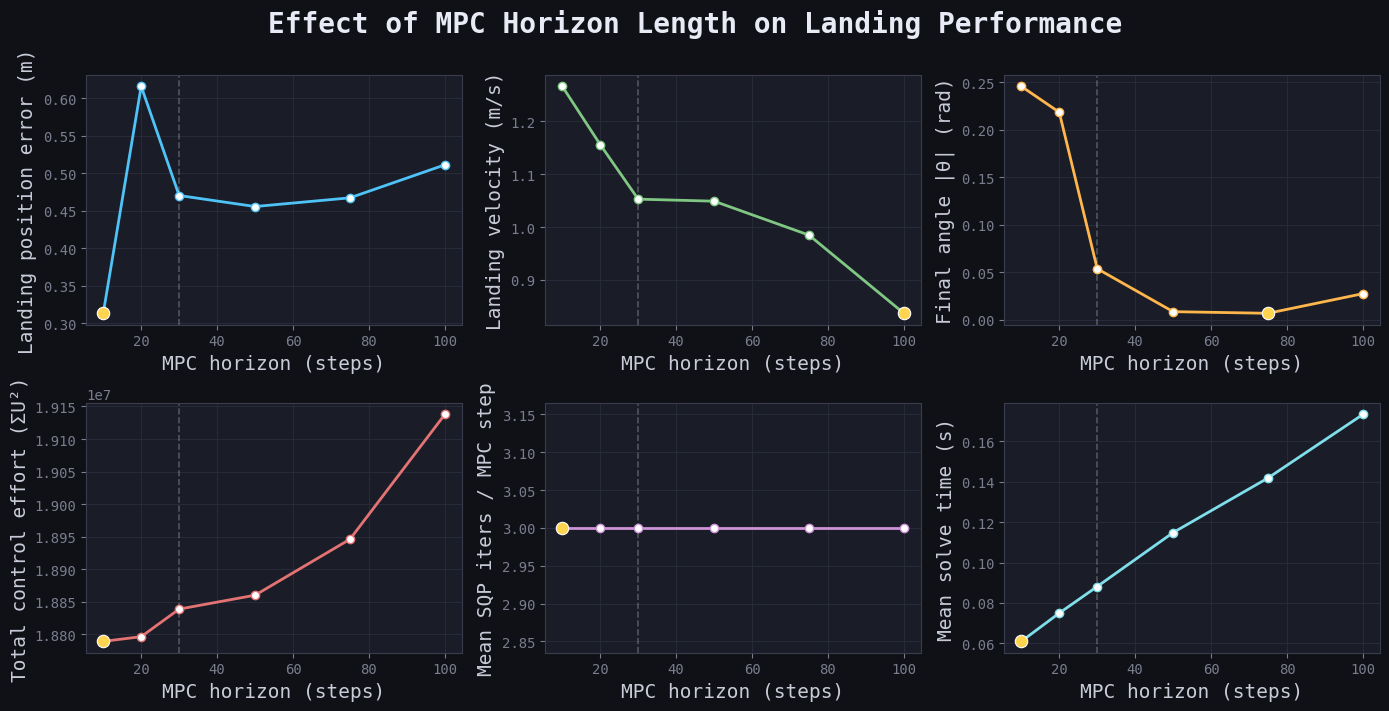

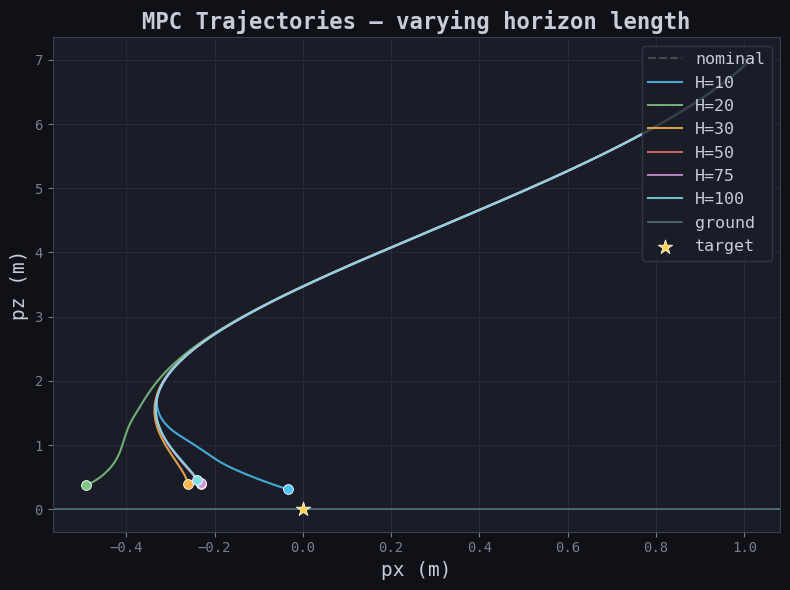

In [9]:
plot_sweep(
    df_horizon, 'mpc_horizon',
    xlabel='MPC horizon (steps)',
    title='Effect of MPC Horizon Length on Landing Performance',
    baseline_val=BASELINE['mpc_horizon'],
)

# trajectory overlay
traj_horizon = {}
for _, row in df_horizon.iterrows():
    val = int(row['swept_value'])
    params = {**BASELINE, 'mpc_horizon': val}
    prob   = build_mpc_problem(params, rocket_ct, lower_control_limit, upper_control_limit)
    met    = run_mpc(prob, rocket_dt, nominal_states, nominal_controls,
                     params, np.array(INITIAL_STATE))
    traj_horizon[f'H={val}'] = met['states']

plot_trajectories_overlay(
    traj_horizon, nominal_states,
    title='MPC Trajectories — varying horizon length',
)

---
## Sweep 2 — Max SQP iterations per MPC step

**Hypothesis:** More SQP iterations per step improves solution quality but increases latency. With a good warm start, diminishing returns appear quickly.

In [10]:
sqp_iter_values = [1, 2, 3, 5, 8, 12]

print('Sweep 2: Max SQP iterations per MPC step')
df_sqp_iters = run_sweep(
    'max_sqp_iterations_tracking', sqp_iter_values, BASELINE,
    nominal_states, nominal_controls,
)
print(df_sqp_iters[['swept_value'] + PLOT_METRICS].to_string(index=False))

Sweep 2: Max SQP iterations per MPC step
  max_sqp_iterations_tracking = 2    max_sqp_iterations_tracking = 3    max_sqp_iterations_tracking = 8    max_sqp_iterations_tracking = 12  

/Users/jimmy/opt/anaconda3/envs/ctrl-3.11/lib/python3.11/site-packages/cvxpy/reductions/solvers/solving_chain_utils.py:30: UserWarning: The problem includes expressions that don't support CPP backend. Defaulting to the SCIPY backend for canonicalization.
  warnings.warn(UserWarning(
/Users/jimmy/opt/anaconda3/envs/ctrl-3.11/lib/python3.11/site-packages/cvxpy/reductions/solvers/solving_chain_utils.py:30: UserWarning: The problem includes expressions that don't support CPP backend. Defaulting to the SCIPY backend for canonicalization.
  warnings.warn(UserWarning(
/Users/jimmy/opt/anaconda3/envs/ctrl-3.11/lib/python3.11/site-packages/cvxpy/reductions/solvers/solving_chain_utils.py:30: UserWarning: The problem includes expressions that don't support CPP backend. Defaulting to the SCIPY backend for canonicalization.
  warnings.warn(UserWarning(
/Users/jimmy/opt/anaconda3/envs/ctrl-3.11/lib/python3.11/site-packages/cvxpy/reductions/solvers/solving_chain_utils.py:30: UserWarning: The problem 

  max_sqp_iterations_tracking = 5    max_sqp_iterations_tracking = 1  

/Users/jimmy/opt/anaconda3/envs/ctrl-3.11/lib/python3.11/site-packages/cvxpy/reductions/solvers/solving_chain_utils.py:30: UserWarning: The problem includes expressions that don't support CPP backend. Defaulting to the SCIPY backend for canonicalization.
  warnings.warn(UserWarning(
/Users/jimmy/opt/anaconda3/envs/ctrl-3.11/lib/python3.11/site-packages/cvxpy/reductions/solvers/solving_chain_utils.py:30: UserWarning: The problem includes expressions that don't support CPP backend. Defaulting to the SCIPY backend for canonicalization.
  warnings.warn(UserWarning(


(20.5s)  pos_err=0.469m
(26.6s)  pos_err=0.491m
(31.0s)  pos_err=0.470m
(38.7s)  pos_err=0.459m
(52.0s)  pos_err=0.456m
(64.1s)  pos_err=0.455m
 swept_value  landing_position_error  landing_velocity  final_angle  total_control_effort  mean_sqp_iterations  mean_solve_time_s
           1                0.469242          1.101501     0.169797          1.878410e+07             1.000000           0.031004
           2                0.490894          1.043410     0.131890          1.883491e+07             2.000000           0.055392
           3                0.470366          1.052942     0.053603          1.883896e+07             3.000000           0.072809
           5                0.459386          1.060223     0.012703          1.883984e+07             4.993333           0.096754
           8                0.455924          1.062534     0.000056          1.884017e+07             7.936667           0.147898
          12                0.454707          1.063316     0.004267         

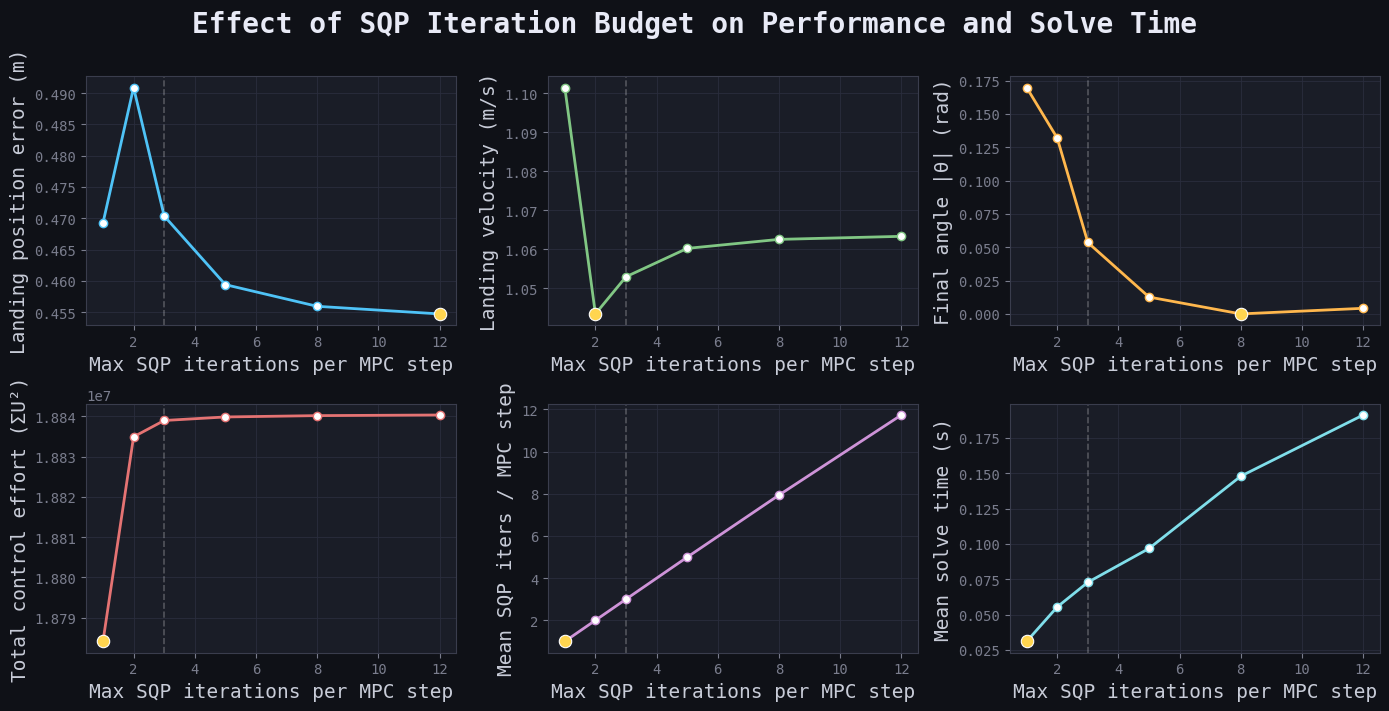

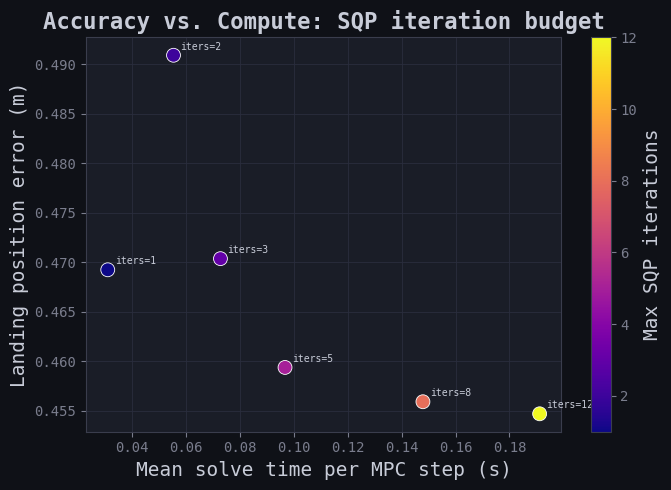

In [11]:
plot_sweep(
    df_sqp_iters, 'max_sqp_iterations_tracking',
    xlabel='Max SQP iterations per MPC step',
    title='Effect of SQP Iteration Budget on Performance and Solve Time',
    baseline_val=BASELINE['max_sqp_iterations_tracking'],
)

# solve time vs accuracy scatter — the key tradeoff plot
fig, ax = plt.subplots(figsize=(7, 5))
sub = df_sqp_iters[df_sqp_iters['swept_param'] == 'max_sqp_iterations_tracking']
sc  = ax.scatter(
    sub['mean_solve_time_s'], sub['landing_position_error'],
    c=sub['swept_value'], cmap='plasma',
    s=100, edgecolors='white', linewidths=0.6, zorder=5,
)
for _, row in sub.iterrows():
    ax.annotate(f"iters={int(row['swept_value'])}",
                (row['mean_solve_time_s'], row['landing_position_error']),
                xytext=(5, 4), textcoords='offset points', fontsize=7, color='#c8ccd8')
plt.colorbar(sc, ax=ax, label='Max SQP iterations')
ax.set_xlabel('Mean solve time per MPC step (s)')
ax.set_ylabel('Landing position error (m)')
ax.set_title('Accuracy vs. Compute: SQP iteration budget', fontweight='bold')
fig.tight_layout()
plt.show()

---
## Sweep 3 — State trust region penalty

**Hypothesis:** A larger state TRP keeps the solver close to the linearization point, improving constraint satisfaction but making the tracking controller less responsive.

In [12]:
state_trp_values = [1.0, 5.0, 10.0, 50.0, 100.0, 500.0, 1000.0]

print('Sweep 3: State trust region penalty')
df_state_trp = run_sweep(
    'state_trust_region_penalty_mpc', state_trp_values, BASELINE,
    nominal_states, nominal_controls,
)
print(df_state_trp[['swept_value'] + PLOT_METRICS].to_string(index=False))

Sweep 3: State trust region penalty
  state_trust_region_penalty_mpc = 1.0    state_trust_region_penalty_mpc = 10.0    state_trust_region_penalty_mpc = 50.0    state_trust_region_penalty_mpc = 5.0    state_trust_region_penalty_mpc = 100.0    state_trust_region_penalty_mpc = 500.0    state_trust_region_penalty_mpc = 1000.0  

/Users/jimmy/opt/anaconda3/envs/ctrl-3.11/lib/python3.11/site-packages/cvxpy/reductions/solvers/solving_chain_utils.py:30: UserWarning: The problem includes expressions that don't support CPP backend. Defaulting to the SCIPY backend for canonicalization.
  warnings.warn(UserWarning(
/Users/jimmy/opt/anaconda3/envs/ctrl-3.11/lib/python3.11/site-packages/cvxpy/reductions/solvers/solving_chain_utils.py:30: UserWarning: The problem includes expressions that don't support CPP backend. Defaulting to the SCIPY backend for canonicalization.
  warnings.warn(UserWarning(
/Users/jimmy/opt/anaconda3/envs/ctrl-3.11/lib/python3.11/site-packages/cvxpy/reductions/solvers/solving_chain_utils.py:30: UserWarning: The problem includes expressions that don't support CPP backend. Defaulting to the SCIPY backend for canonicalization.
  warnings.warn(UserWarning(
/Users/jimmy/opt/anaconda3/envs/ctrl-3.11/lib/python3.11/site-packages/cvxpy/reductions/solvers/solving_chain_utils.py:30: UserWarning: The problem 

(41.3s)  pos_err=0.470m
(41.4s)  pos_err=0.470m
(41.4s)  pos_err=0.470m
(41.5s)  pos_err=0.470m
(41.5s)  pos_err=0.470m
(41.6s)  pos_err=0.471m
(41.5s)  pos_err=0.471m
 swept_value  landing_position_error  landing_velocity  final_angle  total_control_effort  mean_sqp_iterations  mean_solve_time_s
         1.0                0.470362          1.052952     0.053551          1.883896e+07                  3.0           0.097238
         5.0                0.470364          1.052948     0.053574          1.883896e+07                  3.0           0.095746
        10.0                0.470366          1.052942     0.053603          1.883896e+07                  3.0           0.095025
        50.0                0.470385          1.052898     0.053832          1.883897e+07                  3.0           0.096214
       100.0                0.470408          1.052843     0.054117          1.883897e+07                  3.0           0.095070
       500.0                0.470614          1.0523

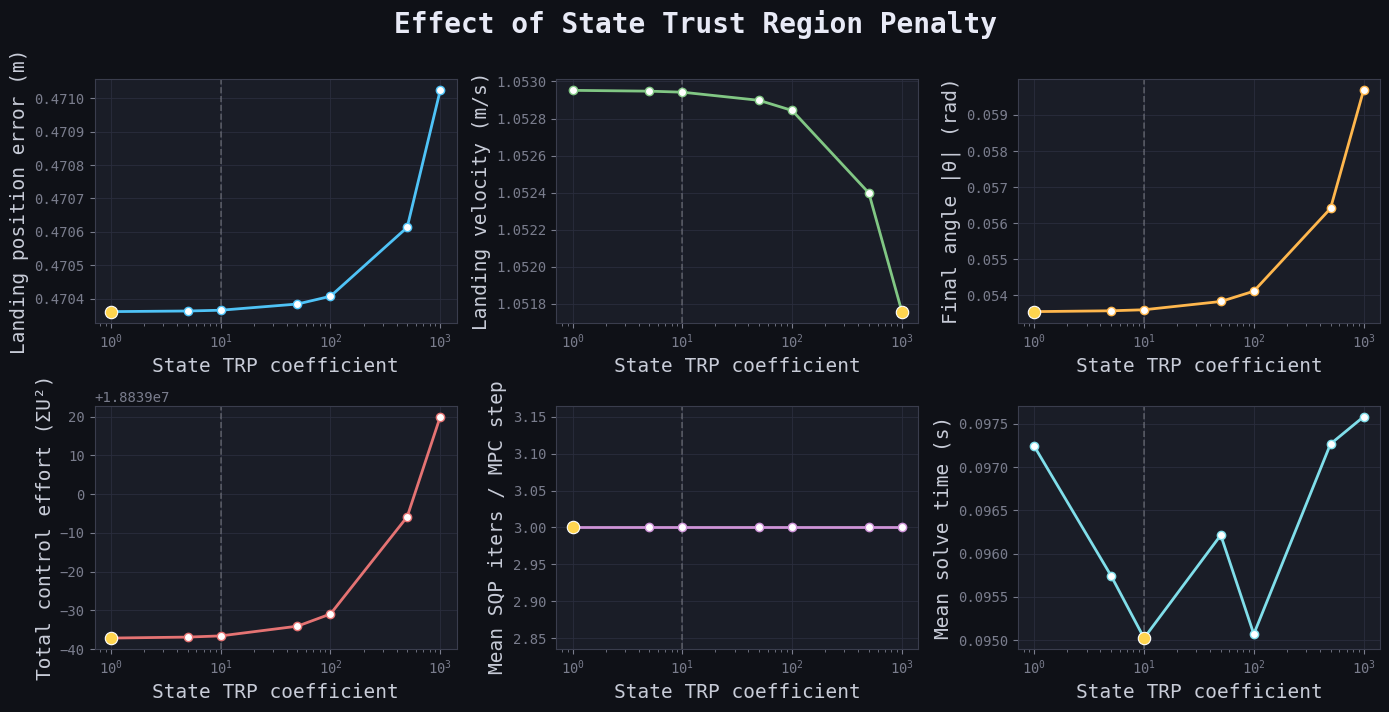

In [13]:
plot_sweep(
    df_state_trp, 'state_trust_region_penalty_mpc',
    xlabel='State TRP coefficient',
    title='Effect of State Trust Region Penalty',
    baseline_val=BASELINE['state_trust_region_penalty_mpc'],
    xscale='log',
)

---
## Sweep 4 — Control trust region penalty

**Hypothesis:** A larger control TRP discourages large control deviations from the warm start, potentially improving smoothness at the cost of aggressiveness.

In [14]:
ctrl_trp_values = [1.0, 5.0, 10.0, 50.0, 100.0, 500.0, 1000.0]

print('Sweep 4: Control trust region penalty')
df_ctrl_trp = run_sweep(
    'control_trust_region_penalty_mpc', ctrl_trp_values, BASELINE,
    nominal_states, nominal_controls,
)
print(df_ctrl_trp[['swept_value'] + PLOT_METRICS].to_string(index=False))

Sweep 4: Control trust region penalty
  control_trust_region_penalty_mpc = 5.0    control_trust_region_penalty_mpc = 1.0    control_trust_region_penalty_mpc = 10.0    control_trust_region_penalty_mpc = 50.0    control_trust_region_penalty_mpc = 100.0    control_trust_region_penalty_mpc = 500.0    control_trust_region_penalty_mpc = 1000.0  

/Users/jimmy/opt/anaconda3/envs/ctrl-3.11/lib/python3.11/site-packages/cvxpy/reductions/solvers/solving_chain_utils.py:30: UserWarning: The problem includes expressions that don't support CPP backend. Defaulting to the SCIPY backend for canonicalization.
  warnings.warn(UserWarning(
/Users/jimmy/opt/anaconda3/envs/ctrl-3.11/lib/python3.11/site-packages/cvxpy/reductions/solvers/solving_chain_utils.py:30: UserWarning: The problem includes expressions that don't support CPP backend. Defaulting to the SCIPY backend for canonicalization.
  warnings.warn(UserWarning(
/Users/jimmy/opt/anaconda3/envs/ctrl-3.11/lib/python3.11/site-packages/cvxpy/reductions/solvers/solving_chain_utils.py:30: UserWarning: The problem includes expressions that don't support CPP backend. Defaulting to the SCIPY backend for canonicalization.
  warnings.warn(UserWarning(
/Users/jimmy/opt/anaconda3/envs/ctrl-3.11/lib/python3.11/site-packages/cvxpy/reductions/solvers/solving_chain_utils.py:30: UserWarning: The problem 

(20.7s)  pos_err=0.939m
(21.9s)  pos_err=0.999m
(29.5s)  pos_err=0.966m
(35.1s)  pos_err=0.531m
(35.5s)  pos_err=0.470m
(35.8s)  pos_err=0.458m
(36.4s)  pos_err=0.454m
 swept_value  landing_position_error  landing_velocity  final_angle  total_control_effort  mean_sqp_iterations  mean_solve_time_s
         1.0                0.453942          1.063728     0.006954          1.884053e+07                  3.0           0.087473
         5.0                0.457844          1.061258     0.007093          1.883997e+07                  3.0           0.085404
        10.0                0.470366          1.052942     0.053603          1.883896e+07                  3.0           0.084962
        50.0                0.530652          1.317509     0.154707          1.819327e+07                  3.0           0.086277
       100.0                0.966349          2.694722     0.151430          1.243647e+07                  3.0           0.094717
       500.0                0.999010          7.4338

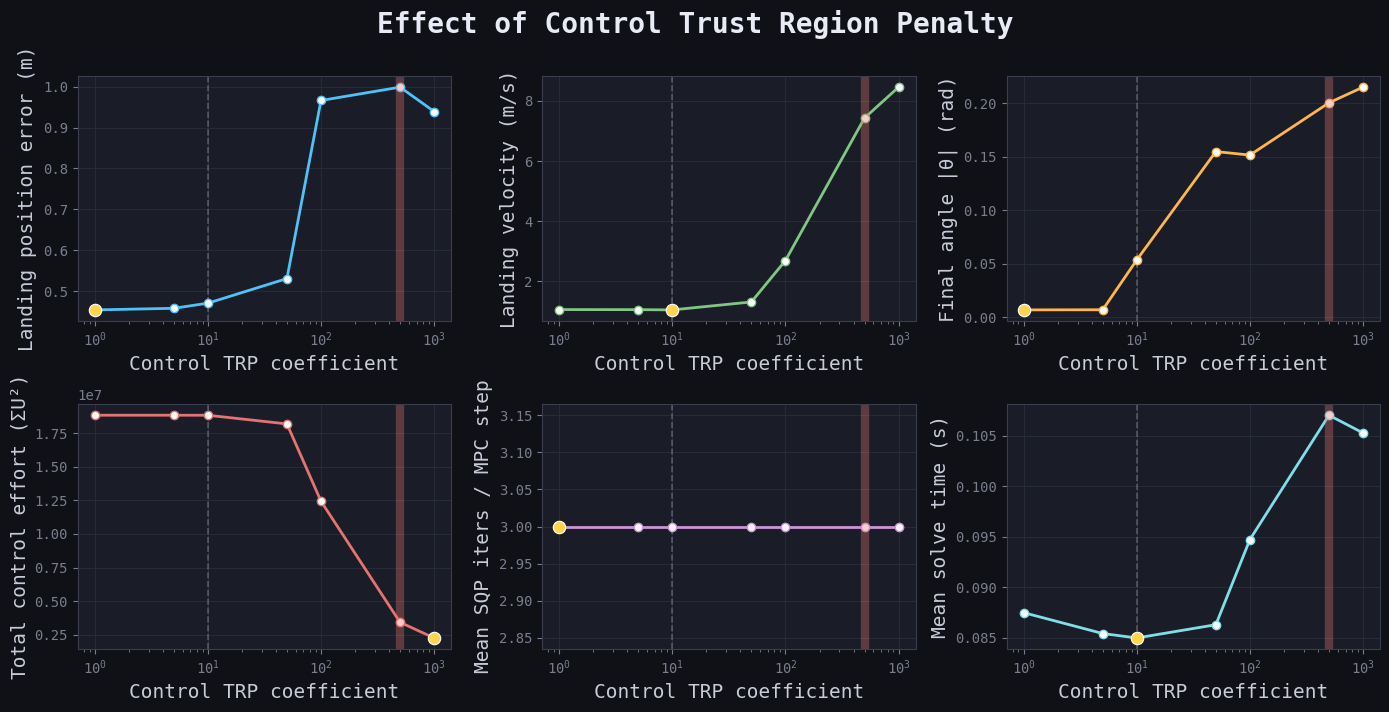

In [15]:
plot_sweep(
    df_ctrl_trp, 'control_trust_region_penalty_mpc',
    xlabel='Control TRP coefficient',
    title='Effect of Control Trust Region Penalty',
    baseline_val=BASELINE['control_trust_region_penalty_mpc'],
    xscale='log',
)

---
## Sweep 5 — Robustness to disturbances

We apply an impulse disturbance to the horizontal velocity at step 50, and vary its magnitude. This tests how well the MPC tracking controller rejects disturbances.

In [16]:
disturbance_magnitudes = [0.0, 2.0, 5.0, 8.0, 12.0, 18.0, 25.0]
DISTURBANCE_STEP = 50   # apply at this MPC step

def make_impulse_disturbance(magnitude: float, step: int = DISTURBANCE_STEP):
    """Returns disturbance_fn that kicks vx at the given step."""
    def disturbance_fn(t, state):
        if t == step:
            kick = np.zeros(state_dim)
            kick[3] = magnitude  # kick horizontal velocity
            return kick
        return np.zeros(state_dim)
    return disturbance_fn


def _run_single_disturbance_config(mag):
    """Worker function for disturbance sweep."""
    jax.config.update('jax_enable_x64', True)
    
    print(f'  disturbance magnitude = {mag}', end='  ', flush=True)
    t0 = time.perf_counter()
    try:
        prob = build_mpc_problem(BASELINE, rocket_ct, lower_control_limit, upper_control_limit)
        met  = run_mpc(
            prob, rocket_dt, nominal_states, nominal_controls,
            BASELINE, np.array(INITIAL_STATE),
            disturbance_fn=make_impulse_disturbance(mag),
        )
    except Exception as e:
        print(f'FAILED: {e}')
        met = {m: np.nan for m in METRICS}
        met['crashed'] = True
        met['states']  = None
    elapsed = time.perf_counter() - t0
    print(f'({elapsed:.1f}s)  pos_err={met["landing_position_error"]:.3f}m  crashed={met["crashed"]}')
    return {'swept_param': 'disturbance_magnitude', 'swept_value': mag, **met}


print('Sweep 5: Disturbance robustness (impulse on vx at step 50)')
records_disturbance = Parallel(n_jobs=-1)(
    delayed(_run_single_disturbance_config)(mag) for mag in disturbance_magnitudes
)
df_disturbance = pd.DataFrame(records_disturbance)

Sweep 5: Disturbance robustness (impulse on vx at step 50)
  disturbance magnitude = 2.0    disturbance magnitude = 5.0    disturbance magnitude = 0.0    disturbance magnitude = 8.0    disturbance magnitude = 12.0    disturbance magnitude = 25.0    disturbance magnitude = 18.0  

/Users/jimmy/opt/anaconda3/envs/ctrl-3.11/lib/python3.11/site-packages/cvxpy/reductions/solvers/solving_chain_utils.py:30: UserWarning: The problem includes expressions that don't support CPP backend. Defaulting to the SCIPY backend for canonicalization.
  warnings.warn(UserWarning(
/Users/jimmy/opt/anaconda3/envs/ctrl-3.11/lib/python3.11/site-packages/cvxpy/reductions/solvers/solving_chain_utils.py:30: UserWarning: The problem includes expressions that don't support CPP backend. Defaulting to the SCIPY backend for canonicalization.
  warnings.warn(UserWarning(
/Users/jimmy/opt/anaconda3/envs/ctrl-3.11/lib/python3.11/site-packages/cvxpy/reductions/solvers/solving_chain_utils.py:30: UserWarning: The problem includes expressions that don't support CPP backend. Defaulting to the SCIPY backend for canonicalization.
  warnings.warn(UserWarning(
/Users/jimmy/opt/anaconda3/envs/ctrl-3.11/lib/python3.11/site-packages/cvxpy/reductions/solvers/solving_chain_utils.py:30: UserWarning: The problem 

(44.3s)  pos_err=0.413m  crashed=False
(44.5s)  pos_err=0.454m  crashed=False
(44.7s)  pos_err=0.470m  crashed=False
(44.6s)  pos_err=0.396m  crashed=False
(44.7s)  pos_err=0.445m  crashed=False
(44.7s)  pos_err=0.398m  crashed=False
(44.8s)  pos_err=0.432m  crashed=False


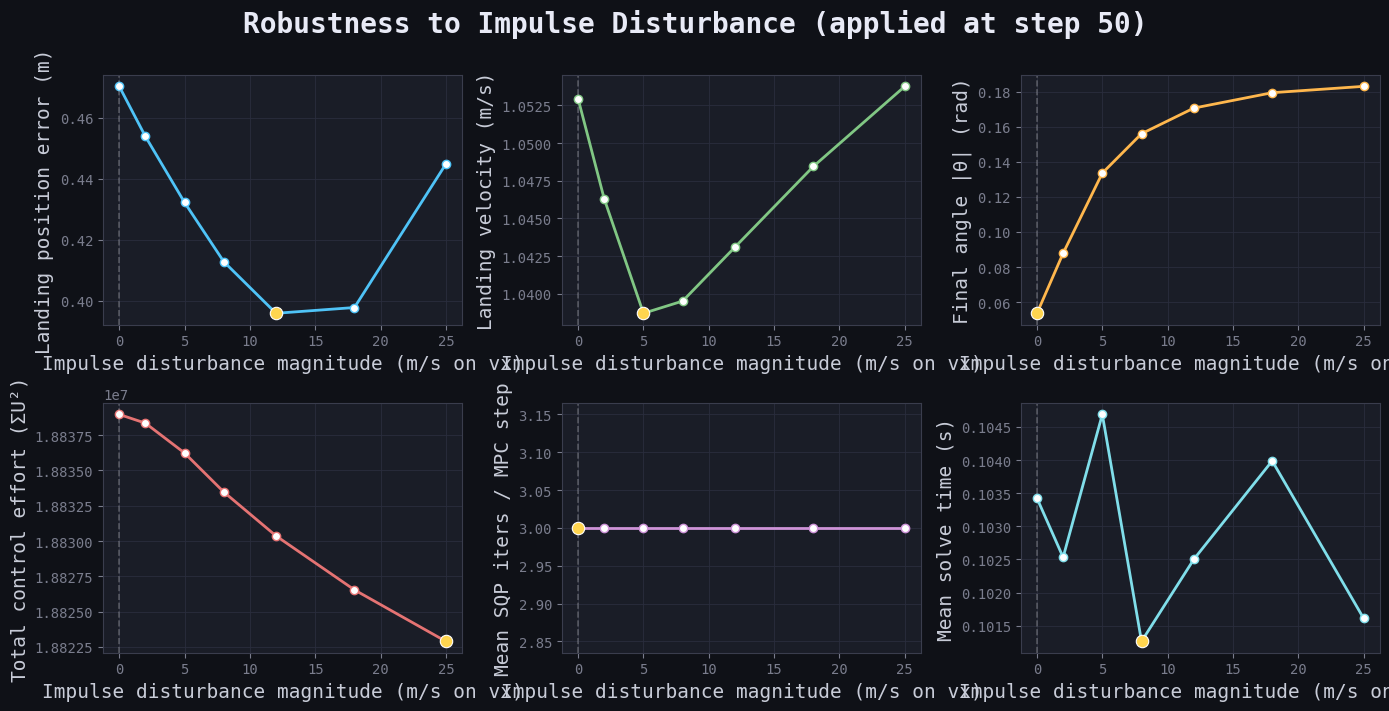

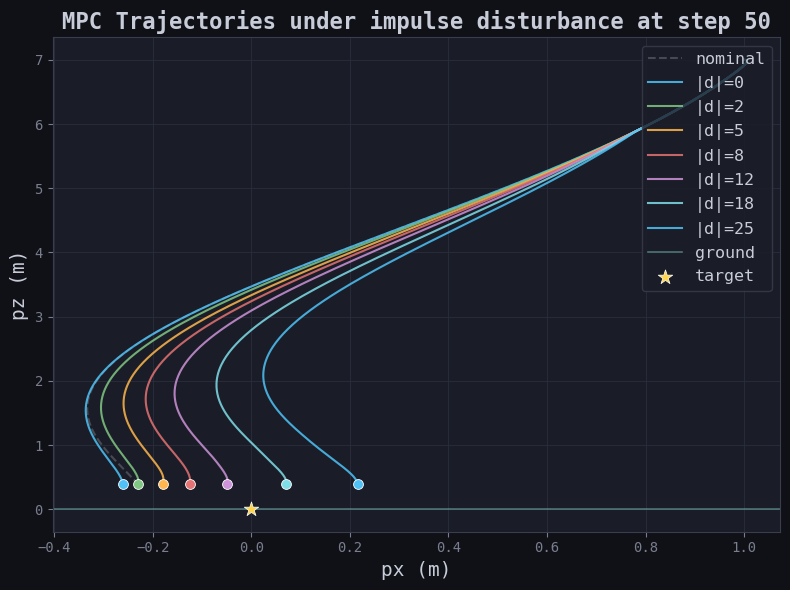

In [17]:
plot_sweep(
    df_disturbance, 'disturbance_magnitude',
    xlabel='Impulse disturbance magnitude (m/s on vx)',
    title=f'Robustness to Impulse Disturbance (applied at step {DISTURBANCE_STEP})',
    baseline_val=0.0,
)

# trajectory overlay showing divergence under increasing disturbance
traj_disturbance = {}
for row in records_disturbance:
    mag = row['swept_value']
    if row.get('states') is not None and not row['crashed']:
        traj_disturbance[f'|d|={mag:.0f}'] = row['states']

if traj_disturbance:
    plot_trajectories_overlay(
        traj_disturbance, nominal_states,
        title=f'MPC Trajectories under impulse disturbance at step {DISTURBANCE_STEP}',
    )

---
## Sweep 6 — Horizon × SQP iterations (2D interaction)

Horizon length and SQP iterations both affect performance and compute. We run a small 2D grid to see how they interact.

In [18]:
horizon_2d   = [15, 30, 50]
sqp_iters_2d = [1, 3, 5]


def _run_single_grid_config(h, s):
    """Worker function for 2D grid sweep."""
    jax.config.update('jax_enable_x64', True)
    
    params = {**BASELINE, 'mpc_horizon': h, 'max_sqp_iterations_tracking': s}
    print(f'  horizon={h}, sqp_iters={s}', end='  ', flush=True)
    t0 = time.perf_counter()
    try:
        prob = build_mpc_problem(params, rocket_ct, lower_control_limit, upper_control_limit)
        met  = run_mpc(prob, rocket_dt, nominal_states, nominal_controls,
                       params, np.array(INITIAL_STATE))
    except Exception as e:
        print(f'FAILED: {e}')
        met = {m: np.nan for m in METRICS}
        met['crashed'] = True
    print(f'({time.perf_counter()-t0:.1f}s)  pos_err={met["landing_position_error"]:.3f}')
    return {'mpc_horizon': h, 'sqp_iters': s, **met}


print('Sweep 6: 2D grid — horizon × SQP iterations')
grid_configs = [(h, s) for h in horizon_2d for s in sqp_iters_2d]
grid_records = Parallel(n_jobs=-1)(
    delayed(_run_single_grid_config)(h, s) for h, s in grid_configs
)
df_grid = pd.DataFrame(grid_records)

Sweep 6: 2D grid — horizon × SQP iterations
  horizon=15, sqp_iters=3    horizon=15, sqp_iters=5    horizon=30, sqp_iters=1    horizon=30, sqp_iters=3    horizon=15, sqp_iters=1    horizon=30, sqp_iters=5    horizon=50, sqp_iters=3    horizon=50, sqp_iters=1  

/Users/jimmy/opt/anaconda3/envs/ctrl-3.11/lib/python3.11/site-packages/cvxpy/reductions/solvers/solving_chain_utils.py:30: UserWarning: The problem includes expressions that don't support CPP backend. Defaulting to the SCIPY backend for canonicalization.
  warnings.warn(UserWarning(
/Users/jimmy/opt/anaconda3/envs/ctrl-3.11/lib/python3.11/site-packages/cvxpy/reductions/solvers/solving_chain_utils.py:30: UserWarning: The problem includes expressions that don't support CPP backend. Defaulting to the SCIPY backend for canonicalization.
  warnings.warn(UserWarning(
/Users/jimmy/opt/anaconda3/envs/ctrl-3.11/lib/python3.11/site-packages/cvxpy/reductions/solvers/solving_chain_utils.py:30: UserWarning: The problem includes expressions that don't support CPP backend. Defaulting to the SCIPY backend for canonicalization.
  warnings.warn(UserWarning(
/Users/jimmy/opt/anaconda3/envs/ctrl-3.11/lib/python3.11/site-packages/cvxpy/reductions/solvers/solving_chain_utils.py:30: UserWarning: The problem 

(22.7s)  pos_err=0.118
  horizon=50, sqp_iters=5  

/Users/jimmy/opt/anaconda3/envs/ctrl-3.11/lib/python3.11/site-packages/cvxpy/reductions/solvers/solving_chain_utils.py:30: UserWarning: The problem includes expressions that don't support CPP backend. Defaulting to the SCIPY backend for canonicalization.
  warnings.warn(UserWarning(


(27.0s)  pos_err=0.469
(30.7s)  pos_err=0.459
(35.0s)  pos_err=0.624
(40.6s)  pos_err=0.470
(43.2s)  pos_err=0.599
(48.5s)  pos_err=0.456
(51.1s)  pos_err=0.459
(44.8s)  pos_err=0.456


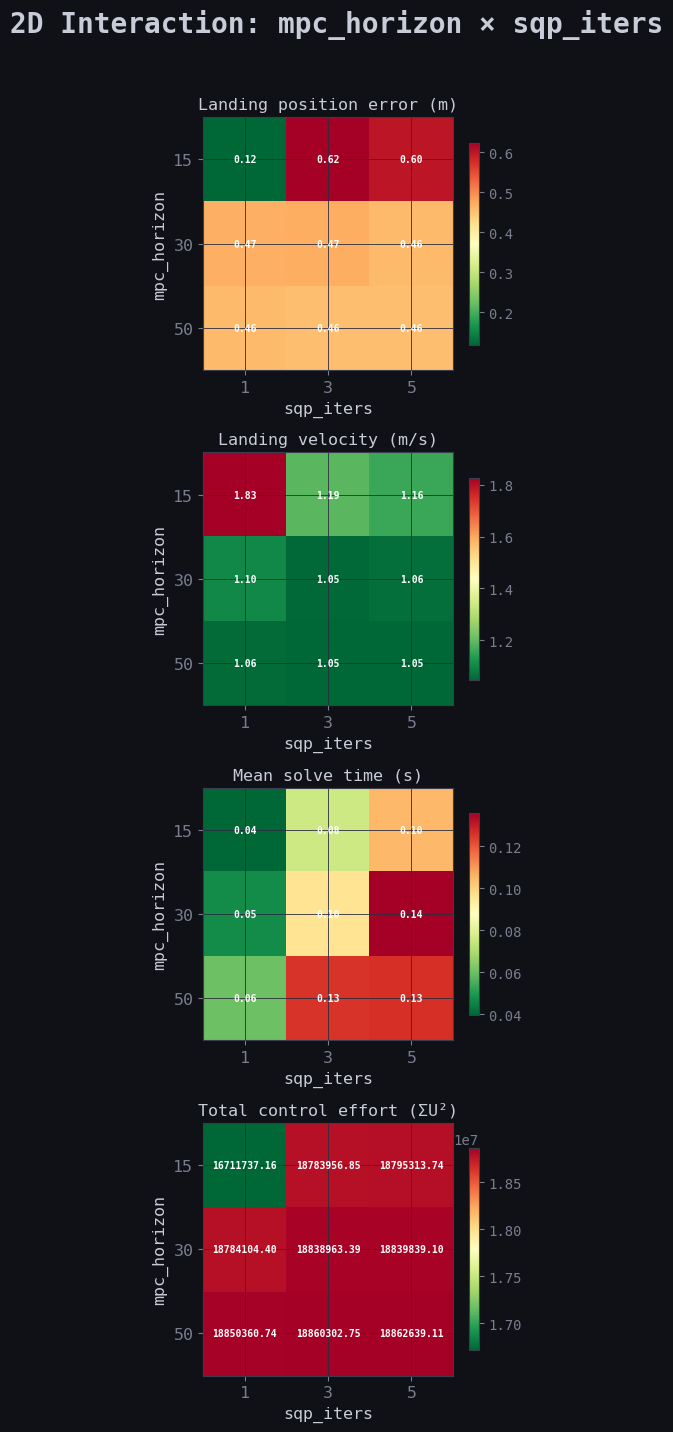

In [19]:
def plot_2d_heatmaps(df_grid, row_vals, col_vals, row_param, col_param):
    metrics_2d = [
        'landing_position_error',
        'landing_velocity',
        'mean_solve_time_s',
        'total_control_effort',
    ]
    fig, axes = plt.subplots(len(metrics_2d), 1, figsize=(4, 14))
    fig.suptitle(f'2D Interaction: {row_param} × {col_param}',
                 fontsize=20, fontweight='bold', y=1.02)

    for ax, metric in zip(axes, metrics_2d):
        Z = np.full((len(row_vals), len(col_vals)), np.nan)
        for i, rv in enumerate(row_vals):
            for j, cv in enumerate(col_vals):
                mask = (df_grid[row_param] == rv) & (df_grid[col_param] == cv)
                rows = df_grid[mask]
                if not rows.empty:
                    Z[i, j] = rows[metric].values[0]

        cmap = 'RdYlGn_r' if LOWER_IS_BETTER[metric] else 'RdYlGn'
        im   = ax.imshow(Z, aspect='auto', cmap=cmap,
                          interpolation='nearest')
        plt.colorbar(im, ax=ax, shrink=0.8)

        # annotate cells
        for i in range(len(row_vals)):
            for j in range(len(col_vals)):
                if not np.isnan(Z[i, j]):
                    ax.text(j, i, f'{Z[i,j]:.2f}', ha='center', va='center',
                            fontsize=7, color='white',
                            fontweight='bold')

        ax.set_xticks(range(len(col_vals)))
        ax.set_xticklabels([str(v) for v in col_vals], fontsize=12)
        ax.set_yticks(range(len(row_vals)))
        ax.set_yticklabels([str(v) for v in row_vals], fontsize=12)
        ax.set_xlabel(col_param, fontsize=12)
        ax.set_ylabel(row_param, fontsize=12)
        ax.set_title(METRIC_LABELS[metric], fontsize=12)

    fig.tight_layout()
    plt.show()


plot_2d_heatmaps(df_grid, horizon_2d, sqp_iters_2d, 'mpc_horizon', 'sqp_iters')

---
## Summary: all sweeps side-by-side

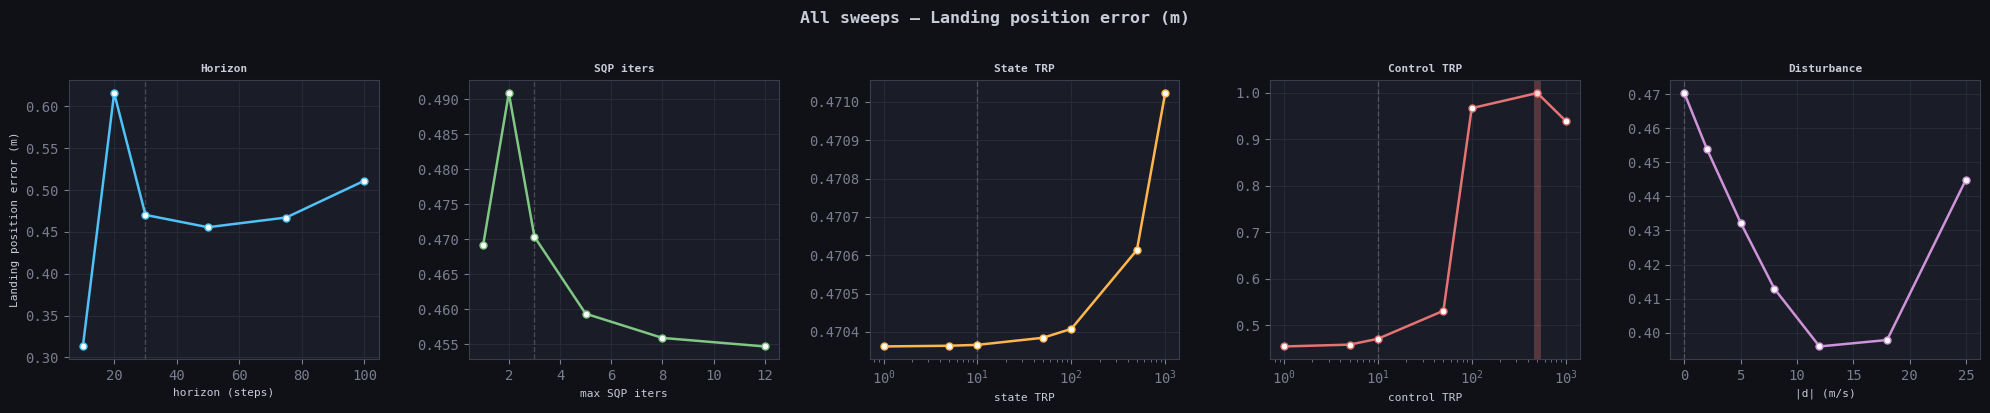

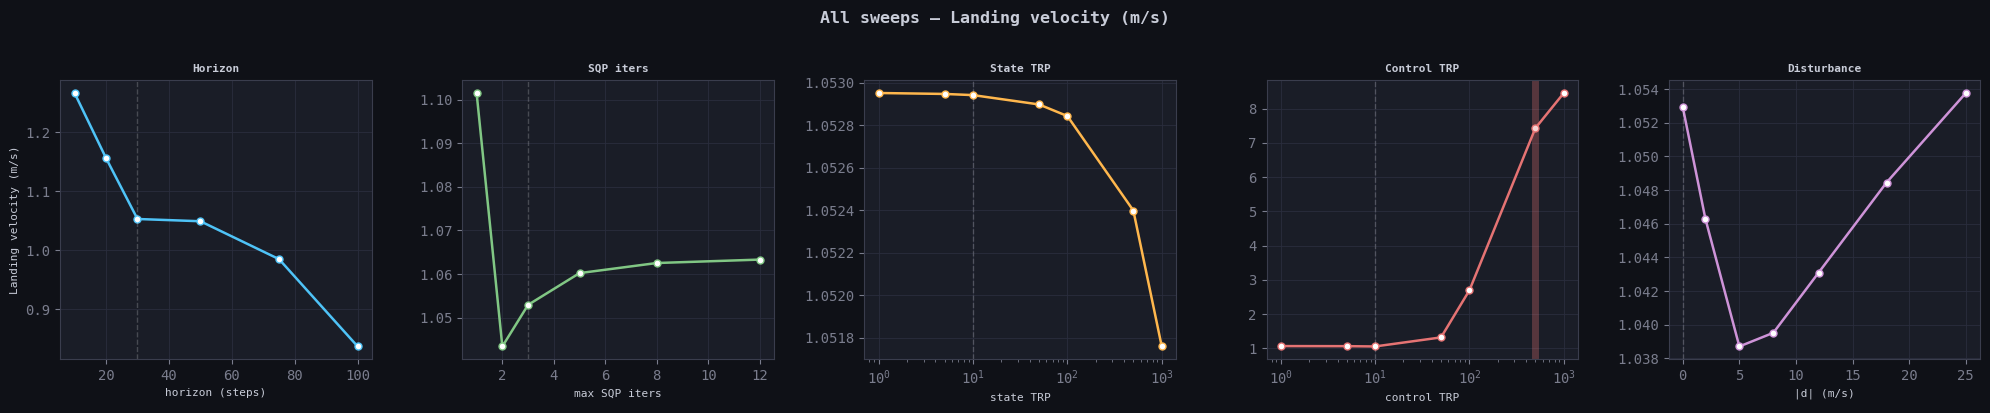

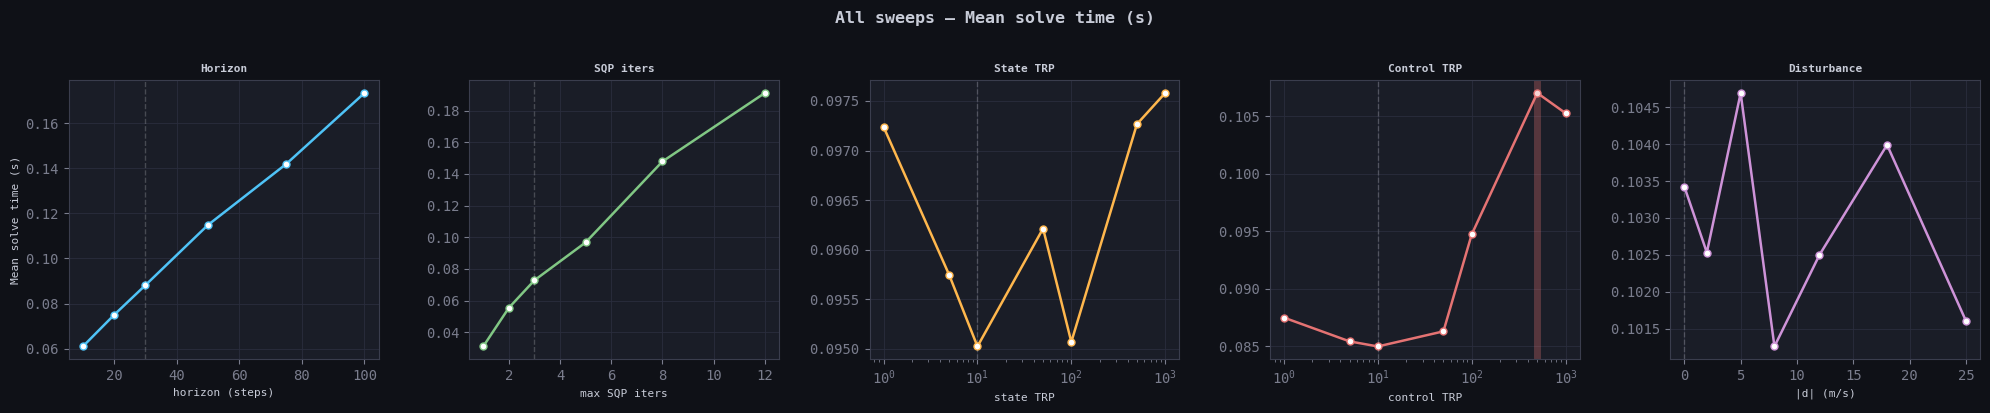

In [20]:
def plot_summary_grid(all_dfs: dict, metric: str):
    """
    One row per sweep, showing a single metric across all sweeps.
    all_dfs: {title: (df, swept_param, xlabel, xscale, baseline_val)}
    """
    n = len(all_dfs)
    fig, axes = plt.subplots(1, n, figsize=(4 * n, 4), sharey=False)
    fig.suptitle(f'All sweeps — {METRIC_LABELS[metric]}',
                 fontsize=12, fontweight='bold', y=1.02)

    for ax, (title, (df, sweep_param, xlabel, xscale, bval)) in zip(axes, all_dfs.items()):
        sub = df[df['swept_param'] == sweep_param]
        x   = sub['swept_value'].values
        y   = sub[metric].values.astype(float)
        col = ACCENT[list(all_dfs.keys()).index(title) % len(ACCENT)]

        ax.plot(x, y, color=col, marker=MARKER, markersize=5,
                markerfacecolor='white', markeredgecolor=col)
        if bval is not None:
            ax.axvline(bval, color='white', alpha=0.2, linestyle='--', linewidth=1)

        crashed = sub['crashed'].values.astype(bool)
        for cx in x[crashed]:
            ax.axvline(cx, color='#e57373', alpha=0.3, linewidth=5)

        ax.set_xscale(xscale)
        ax.set_xlabel(xlabel, fontsize=8)
        ax.set_title(title, fontsize=8, fontweight='bold')
        if ax == axes[0]:
            ax.set_ylabel(METRIC_LABELS[metric], fontsize=8)

    fig.tight_layout()
    plt.show()


sweep_registry = {
    'Horizon':        (df_horizon,     'mpc_horizon',                       'horizon (steps)', 'linear', BASELINE['mpc_horizon']),
    'SQP iters':      (df_sqp_iters,   'max_sqp_iterations_tracking',       'max SQP iters',   'linear', BASELINE['max_sqp_iterations_tracking']),
    'State TRP':      (df_state_trp,   'state_trust_region_penalty_mpc',    'state TRP',       'log',    BASELINE['state_trust_region_penalty_mpc']),
    'Control TRP':    (df_ctrl_trp,    'control_trust_region_penalty_mpc',  'control TRP',     'log',    BASELINE['control_trust_region_penalty_mpc']),
    'Disturbance':    (df_disturbance, 'disturbance_magnitude',             '|d| (m/s)',       'linear', 0.0),
}

for summary_metric in ['landing_position_error', 'landing_velocity', 'mean_solve_time_s']:
    plot_summary_grid(sweep_registry, summary_metric)

## Recommended parameter ranges

Based on the sweep results above, print a table of recommended values.

In [21]:
def best_value(df, swept_param, metric, lower_is_better=True):
    """Return the swept value that minimizes (or maximizes) a metric, ignoring crashed runs."""
    sub = df[(df['swept_param'] == swept_param) & (~df['crashed'].astype(bool))]
    if sub.empty:
        return None
    idx = sub[metric].idxmin() if lower_is_better else sub[metric].idxmax()
    return sub.loc[idx, 'swept_value']


print('\n=== Recommended parameter values (based on landing_position_error) ===')
print(f'{"Parameter":<45} {"Best value":<15} {"Baseline"}')
print('-' * 75)
recommendations = [
    ('mpc_horizon',                      df_horizon,    'landing_position_error', BASELINE['mpc_horizon']),
    ('max_sqp_iterations_tracking',      df_sqp_iters,  'landing_position_error', BASELINE['max_sqp_iterations_tracking']),
    ('state_trust_region_penalty_mpc',   df_state_trp,  'landing_position_error', BASELINE['state_trust_region_penalty_mpc']),
    ('control_trust_region_penalty_mpc', df_ctrl_trp,   'landing_position_error', BASELINE['control_trust_region_penalty_mpc']),
]
for param, df, metric, baseline_val in recommendations:
    bv = best_value(df, param, metric)
    print(f'{param:<45} {str(bv):<15} {baseline_val}')

print('\n=== Recommended parameter values (best compute efficiency: min solve time) ===')
print(f'{"Parameter":<45} {"Best value":<15} {"Baseline"}')
print('-' * 75)
for param, df, _, baseline_val in recommendations:
    bv = best_value(df, param, 'mean_solve_time_s')
    print(f'{param:<45} {str(bv):<15} {baseline_val}')

print('\n=== Disturbance rejection: max tolerated impulse before crash ===')
survived = df_disturbance[~df_disturbance['crashed'].astype(bool)]
if not survived.empty:
    max_tolerated = survived['swept_value'].max()
    print(f'Max tolerated vx impulse: {max_tolerated:.1f} m/s')
else:
    print('No disturbance runs survived.')


=== Recommended parameter values (based on landing_position_error) ===
Parameter                                     Best value      Baseline
---------------------------------------------------------------------------
mpc_horizon                                   10              30
max_sqp_iterations_tracking                   12              3
state_trust_region_penalty_mpc                1.0             10.0
control_trust_region_penalty_mpc              1.0             10.0

=== Recommended parameter values (best compute efficiency: min solve time) ===
Parameter                                     Best value      Baseline
---------------------------------------------------------------------------
mpc_horizon                                   10              30
max_sqp_iterations_tracking                   1               3
state_trust_region_penalty_mpc                10.0            10.0
control_trust_region_penalty_mpc              10.0            10.0

=== Disturbance rejection: 

## Save all results

In [22]:
all_results = pd.concat([
    df_horizon,
    df_sqp_iters,
    df_state_trp,
    df_ctrl_trp,
    df_disturbance,
], ignore_index=True)

# drop trajectory arrays before saving (not serialisable)
cols_to_drop = [c for c in all_results.columns if c in ('states', 'controls')]
all_results.drop(columns=cols_to_drop, errors='ignore').to_csv('sweep_results.csv', index=False)
print('Results saved to sweep_results.csv')
all_results.head()

Results saved to sweep_results.csv


,swept_param,swept_value,states,controls,landing_position_error,landing_velocity,final_angle,total_control_effort,crashed,steps_taken,mean_sqp_iterations,max_sqp_iterations,mean_solve_time_s,total_solve_time_s,n_solver_failures
0,mpc_horizon,10.0,"[[1.0, 7.0, 0.10000000149011612, 0.20000000298...","[[-56.34938304983694, 4.8731464025415, -10.395...",0.313137,1.266524,0.245475,1.878942e+07,False,300,3.0,3.0,0.060969,18.290758,0
1,mpc_horizon,20.0,"[[1.0, 7.0, 0.10000000149011612, 0.20000000298...","[[-56.349383049849656, 4.8731464025547195, -10...",0.616091,1.156213,0.218232,1.879664e+07,False,300,3.0,3.0,0.074972,22.491520,0
2,mpc_horizon,30.0,"[[1.0, 7.0, 0.10000000149011612, 0.20000000298...","[[-56.34938304971935, 4.873146402564718, -10.3...",0.470366,1.052942,0.053603,1.883896e+07,False,300,3.0,3.0,0.088146,26.443729,0
3,mpc_horizon,50.0,"[[1.0, 7.0, 0.10000000149011612, 0.20000000298...","[[-56.34938304588808, 4.873146402240835, -10.3...",0.455652,1.049108,0.008409,1.886030e+07,False,300,3.0,3.0,0.114853,34.455894,0
4,mpc_horizon,75.0,"[[1.0, 7.0, 0.10000000149011612, 0.20000000298...","[[-56.34938303352504, 4.873146401104204, -10.3...",0.467272,0.984860,0.006708,1.894620e+07,False,300,3.0,3.0,0.141890,42.567141,0
